# AI Music Generation

## 📚 Learning Objectives

By completing this notebook, you will:
- Use or adapt models for music generation
- Understand representation and evaluation challenges

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

---

# AI Music Generation
## AIAT 124 - Generative AI

## Learning Objectives

- Generate music with RNN/LSTM
- Understand music representation
- Create melodies and harmonies
- Apply to music composition

## Real-World Context

Music composition, background music generation, and creative audio content.

**Industry Impact**: Used by Spotify, YouTube, and music production tools.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: numpy for audio math, torch for the LSTM music model, matplotlib for piano rolls.
# WHY: we generate real (toy-scale) music in this notebook — notes as tokens, an LSTM as
# the composer, and a sine-wave synthesizer so you can actually LISTEN to the result.
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
print('✅ Setup complete!')

✅ Setup complete!


## Part 1: Music Representation

Before a model can generate music, music must become **numbers**. The standard choices:

1. **MIDI note numbers** — each pitch is an integer (middle C = 60, C# = 61, ... +12 per octave)
2. **Piano roll** — a 2-D grid: pitch on the y-axis, time on the x-axis
3. **Token sequence** — read the piano roll left-to-right and music becomes a sequence,
   *exactly like text* — which is why language-model techniques work on it

Below we encode two real public-domain melodies and draw their piano rolls.

Ode to Joy as MIDI numbers : [64, 64, 65, 67, 67, 65, 64, 62, 60, 60, 62, 64, 64, 62, 62]
...as note names           : ['E4', 'E4', 'F4', 'G4', 'G4', 'F4', 'E4', 'D4', 'C4', 'C4', 'D4', 'E4', 'E4', 'D4', 'D4']


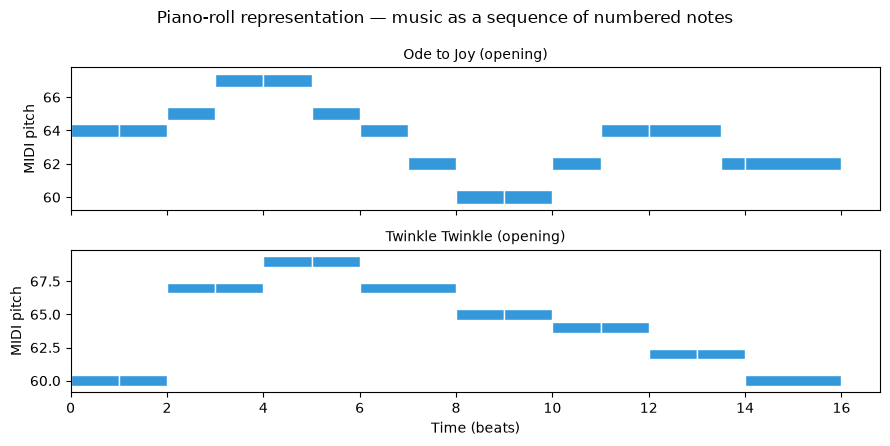

In [2]:
# Encode two real melodies as MIDI note-number sequences and draw their piano rolls.
# WHY: this is the "tokenization" step — once melodies are integer sequences, the same
# next-token modeling we used for text applies directly to music.

# ── Melodies as (MIDI pitch, duration-in-beats) pairs — public domain ─────
# "Ode to Joy" (Beethoven) opening phrase, in C major
ode = [(64,1),(64,1),(65,1),(67,1),(67,1),(65,1),(64,1),(62,1),
       (60,1),(60,1),(62,1),(64,1),(64,1.5),(62,.5),(62,2)]
# "Twinkle Twinkle Little Star" opening phrase, in C major
twinkle = [(60,1),(60,1),(67,1),(67,1),(69,1),(69,1),(67,2),
           (65,1),(65,1),(64,1),(64,1),(62,1),(62,1),(60,2)]

NOTE_NAMES = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
def name(pitch):
    """MIDI number -> human-readable note name (60 -> C4)."""
    return f"{NOTE_NAMES[pitch % 12]}{pitch // 12 - 1}"

print("Ode to Joy as MIDI numbers :", [p for p, d in ode])
print("...as note names           :", [name(p) for p, d in ode])

# ── Piano roll: pitch (y) against time in beats (x) ───────────────────────
fig, axes = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True)
for ax, (title, mel) in zip(axes, [("Ode to Joy (opening)", ode),
                                   ("Twinkle Twinkle (opening)", twinkle)]):
    t = 0
    for pitch, dur in mel:
        ax.barh(pitch, dur, left=t, height=0.8, color='#3498db', edgecolor='white')
        t += dur
    ax.set_title(title, fontsize=10); ax.set_ylabel("MIDI pitch")
axes[1].set_xlabel("Time (beats)")
plt.suptitle("Piano-roll representation — music as a sequence of numbered notes")
plt.tight_layout(); plt.show()

## Part 2: An LSTM That Learns to Compose

Now the generative model. We treat each pitch as a **token** and train an LSTM to predict the
next note from the previous few — identical to the char-level language models of Unit 2, with
an alphabet of pitches instead of letters. Training data: the two melodies above.

In [3]:
# Build and train the LSTM music generator: next-note prediction over pitch tokens.
# WHY: melody continuation IS next-token prediction — the same loss and loop as a text LM.
torch.manual_seed(0); np.random.seed(0)

# ── Tokenize: pitch vocabulary from the training melodies ─────────────────
corpus_notes = [p for p, d in ode] + [p for p, d in twinkle]
pitches = sorted(set(corpus_notes))                 # our note "alphabet"
p2i = {p: i for i, p in enumerate(pitches)}
i2p = {i: p for p, i in p2i.items()}
V, SEQ = len(pitches), 4                            # predict note 5 from previous 4
print(f"Pitch vocabulary ({V} notes): {[name(p) for p in pitches]}")

# ── Training windows: 4 notes in -> 1 note out ────────────────────────────
enc = [p2i[p] for p in corpus_notes]
X = torch.tensor([enc[i:i+SEQ] for i in range(len(enc)-SEQ)], dtype=torch.long)
y = torch.tensor([enc[i+SEQ] for i in range(len(enc)-SEQ)], dtype=torch.long)

class MusicGenerator(nn.Module):
    """LSTM-based next-note model: embed pitch tokens, run LSTM, predict next pitch."""
    def __init__(self, vocab_size, embedding_dim=16, hidden=64):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embedding_dim)   # pitch id -> vector
        self.lstm  = nn.LSTM(embedding_dim, hidden, batch_first=True)
        self.fc    = nn.Linear(hidden, vocab_size)             # hidden state -> next-pitch logits
    def forward(self, x):
        out, _ = self.lstm(self.embed(x))
        return self.fc(out[:, -1, :])                          # predict from last timestep

model = MusicGenerator(V)
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()

# ── Train: full-batch (tiny dataset) for 300 steps ────────────────────────
for step in range(300):
    model.train()
    loss = loss_fn(model(X), y)
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 100 == 0:
        print(f"Step {step:3d} — loss: {loss.item():.3f}")
print(f"Final    — loss: {loss.item():.3f}")
print('✅ MusicGenerator trained on the two melodies')

Pitch vocabulary (6 notes): ['C4', 'D4', 'E4', 'F4', 'G4', 'A4']


Step   0 — loss: 1.779
Step 100 — loss: 0.000
Step 200 — loss: 0.000
Final    — loss: 0.000
✅ MusicGenerator trained on the two melodies


## Part 3: Generate a Melody — and Listen to It

We seed the model with the first notes of *Ode to Joy* and sample the next 24 notes with
**temperature sampling** (same trick as in text generation: higher temperature = more surprising
note choices). Then we synthesize the result as an actual sine-wave audio clip you can play,
and **evaluate** it with two simple computed checks — the evaluation problem is exactly why
generative music research is hard: there is no single "accuracy" for a melody.

**Honest expectation:** with only two short training melodies, the model mostly *reproduces and
blends* what it memorized (watch it drift from *Ode to Joy* into *Twinkle* patterns). Novel
composition needs far more data — that is precisely what separates this demo from MuseNet.

Seed     : ['E4', 'E4', 'F4', 'G4']
Generated: ['G4', 'F4', 'E4', 'D4', 'C4', 'C4', 'D4', 'E4', 'E4', 'D4', 'D4', 'C4', 'C4', 'G4', 'G4', 'A4', 'A4', 'G4', 'F4', 'F4', 'E4', 'E4', 'D4', 'D4']


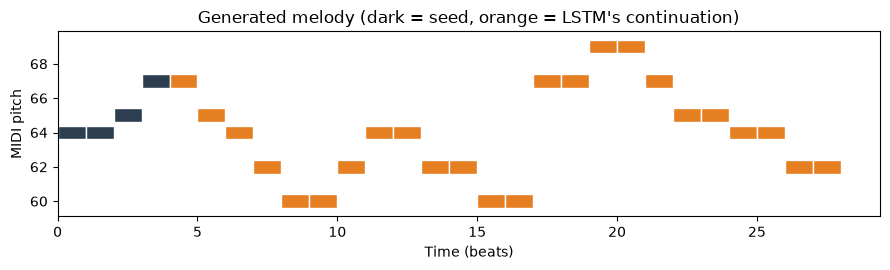

Synthesized 8.4s of audio — press play:



Computed checks on the generated continuation:
  Notes in C major scale : 100%  (training melodies: 100%)
  Stepwise motion (≤2 st): 96%  (smooth melodies score high)
These are heuristics, not ground truth — evaluating generative music remains an open problem.


In [4]:
# Generate a new melody with the trained LSTM, visualize it, synthesize audio, and
# compute simple quality checks. WHY: closes the loop — represent, model, generate, evaluate.
from IPython.display import Audio, display

def generate_melody(seed_pitches, n_notes=24, temperature=0.8):
    """Autoregressively sample n_notes continuing the seed (temperature sampling)."""
    model.eval()
    seq = [p2i[p] for p in seed_pitches]
    for _ in range(n_notes):
        ctx = torch.tensor([seq[-SEQ:]], dtype=torch.long)
        with torch.no_grad():
            logits = model(ctx)[0] / max(temperature, 1e-6)
        probs = torch.softmax(logits, 0).numpy()
        seq.append(int(np.random.choice(V, p=probs)))          # sample, don't argmax
    return [i2p[i] for i in seq]

seed = [p for p, d in ode[:4]]                                  # first 4 notes of Ode to Joy
melody = generate_melody(seed, n_notes=24, temperature=0.8)
print("Seed     :", [name(p) for p in seed])
print("Generated:", [name(p) for p in melody[len(seed):]])

# ── Piano roll of the generated melody (seed shown darker) ────────────────
fig, ax = plt.subplots(figsize=(9, 2.8))
for t, pitch in enumerate(melody):
    ax.barh(pitch, 1, left=t, height=0.8,
            color='#2c3e50' if t < len(seed) else '#e67e22', edgecolor='white')
ax.set_xlabel("Time (beats)"); ax.set_ylabel("MIDI pitch")
ax.set_title("Generated melody (dark = seed, orange = LSTM's continuation)")
plt.tight_layout(); plt.show()

# ── Synthesize audio: one sine wave per note + a fade envelope ────────────
SR, BEAT = 8000, 0.3                                            # sample rate, seconds per beat
def midi_to_hz(p):
    return 440.0 * 2 ** ((p - 69) / 12)                         # standard MIDI tuning formula
wave = np.concatenate([
    np.sin(2 * np.pi * midi_to_hz(p) * np.arange(int(SR * BEAT)) / SR)
    * np.linspace(1, 0.2, int(SR * BEAT))                       # decay envelope, avoids clicks
    for p in melody])
print(f"Synthesized {len(wave)/SR:.1f}s of audio — press play:")
display(Audio(wave, rate=SR))

# ── Evaluate with computed checks (no single 'accuracy' exists for music) ─
gen = melody[len(seed):]
in_key = np.mean([p % 12 in {0, 2, 4, 5, 7, 9, 11} for p in gen])   # C-major scale membership
steps = np.abs(np.diff(gen))
stepwise = np.mean(steps <= 2) if len(steps) else 0.0               # melodic = mostly small steps
print(f"\nComputed checks on the generated continuation:")
print(f"  Notes in C major scale : {in_key:.0%}  (training melodies: 100%)")
print(f"  Stepwise motion (≤2 st): {stepwise:.0%}  (smooth melodies score high)")
print("These are heuristics, not ground truth — evaluating generative music remains an open problem.")

## Real-World Applications

- **Content Creation**: Background music for videos
- **Music Production**: Melody and harmony generation
- **Gaming**: Dynamic soundtracks
- **Education**: Music learning tools

## 📝 Summary

In this notebook, you:

- Encoded real melodies as **MIDI note numbers** and drew their **piano rolls** — turning music
  into token sequences
- Trained an **LSTM next-note model** (`MusicGenerator`) on two melodies — the same
  language-modeling recipe as Unit 2, over a pitch alphabet
- **Generated and listened to** a new melody via temperature sampling + sine-wave synthesis
- Evaluated it with computed heuristics (scale membership, stepwise motion) and saw why music
  evaluation is an open research problem

**Scaling this up:** real systems (Music Transformer, MuseNet, Suno) use the same
sequence-modeling idea with transformers, richer tokens (velocity, timing, instruments), and
millions of MIDI files — or skip symbols entirely and generate raw audio (Jukebox, notebook `05`).

## 📚 References & Further Reading

**Papers:**
- Huang et al. (2018) — [Music Transformer](https://arxiv.org/abs/1809.04281)
- Dhariwal et al. (2020) — [Jukebox: A Generative Model for Music](https://arxiv.org/abs/2005.00341)
- Copet et al. (2023) — [Simple and Controllable Music Generation (MusicGen)](https://arxiv.org/abs/2306.05284)

**Interactive:**
- [Google Magenta](https://magenta.tensorflow.org/) — open-source music-generation research + demos
- [The Unreasonable Effectiveness of RNNs](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)

**State-of-the-Art:** Suno and Udio generate full songs (vocals + instruments) from text prompts,
using audio-token language models descended from Jukebox.